In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score,\
    f1_score, roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GroupShuffleSplit,\
    GroupKFold, GridSearchCV, RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from sklearn import svm
from sklearn.svm import SVC
import lightgbm as lgb
import xgboost 

In [2]:
import os
import warnings
import pandas as pd
import features as f
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
import statistics

warnings.filterwarnings('ignore')

parent = os.path.dirname(os.getcwd())

data = pd.read_csv(parent+"\\data\\MEM_Features_01_BERT.csv")
data = data.drop("Unnamed: 0", axis=1)
data.head()

,LISTID,PRESENTED_WORD,PRESENT_POSITION,HIT,PARTICIPANT_GROUP,PID,MOST_SIM_VAL,MOST_SIM_DIST,AVG_SIM_PREV_2,AVG_CONTRAST_2,PREV_SIM,PRESENT_ZONE,P_ID
0,1,KALEM,1,1,soc,9soc,NaN,NaN,NaN,0.148011,NaN,1,soc9
1,1,ÖLÇEK,2,0,soc,9soc,0.210581,1.0,0.210581,0.166260,0.210581,1,soc9
2,1,ÇANTA,3,0,soc,9soc,0.233328,1.0,0.211125,0.098606,0.233328,1,soc9
3,1,AĞAÇ,4,1,soc,9soc,0.213931,3.0,0.156147,0.083086,0.109956,1,soc9
4,1,PARK,5,0,soc,9soc,0.194001,3.0,0.148407,0.111218,0.148786,2,soc9


In [3]:
data.isna().sum()

LISTID                 0
PRESENTED_WORD         0
PRESENT_POSITION       0
HIT                    0
PARTICIPANT_GROUP      0
PID                    0
MOST_SIM_VAL         176
MOST_SIM_DIST        176
AVG_SIM_PREV_2       176
AVG_CONTRAST_2         0
PREV_SIM             176
PRESENT_ZONE           0
P_ID                   0
dtype: int64

In [4]:
#FOR NOW, FILLING THESE IN WITH WHAT I THINK TO BE FIT 
#WILL EDIT, BUT I JUST REPLACE WITH MEAN TO NOT DISTURB THE DISTRIBUTION
#MAYBE WE CAN DO THIS: USE PARTICIPANT WIDE SIM CALCULATIONS, SO WE HAVE LESS NA.
#AND ON PREV WE CAN TURN INTO AVG_SIM, WHICH WILL INCLUDE LATER WORDS AS WELL
for col in data.columns:
    if data[col].isna().sum() > 0: 
        data[col] = data[col].fillna(np.mean(data[col]))
data.isna().sum()

LISTID               0
PRESENTED_WORD       0
PRESENT_POSITION     0
HIT                  0
PARTICIPANT_GROUP    0
PID                  0
MOST_SIM_VAL         0
MOST_SIM_DIST        0
AVG_SIM_PREV_2       0
AVG_CONTRAST_2       0
PREV_SIM             0
PRESENT_ZONE         0
P_ID                 0
dtype: int64

In [5]:
cols_categorical = ["LISTID", "PARTICIPANT_GROUP", "PRESENT_ZONE"]
cols_numeric = ["PRESENT_POSITION", "MOST_SIM_VAL", "MOST_SIM_DIST",
                "AVG_SIM_PREV_2", "AVG_CONTRAST_2", "PREV_SIM"]
target = data["HIT"]
data = data.drop(["HIT", "PRESENTED_WORD"], axis = 1)

In [6]:
X_df = data[cols_categorical + cols_numeric]
encoder = OneHotEncoder()

X_encoded = encoder.fit_transform(X_df[cols_categorical]).toarray()
encoded_feature_names = encoder.get_feature_names_out(cols_categorical)
encoded_feature_names = list(encoded_feature_names)

X_numeric = X_df[cols_numeric]

X_df = np.hstack([X_encoded, X_numeric])
X_df = pd.DataFrame(data = X_df, columns=encoded_feature_names+cols_numeric)

X_df

,LISTID_1,LISTID_2,LISTID_3,LISTID_4,PARTICIPANT_GROUP_eng,PARTICIPANT_GROUP_soc,PRESENT_ZONE_1,PRESENT_ZONE_2,PRESENT_ZONE_3,PRESENT_POSITION,MOST_SIM_VAL,MOST_SIM_DIST,AVG_SIM_PREV_2,AVG_CONTRAST_2,PREV_SIM
0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.312990,6.827972,0.200367,0.148011,0.192781
1,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,0.210581,1.000000,0.210581,0.166260,0.210581
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,0.233328,1.000000,0.211125,0.098606,0.233328
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,4.0,0.213931,3.000000,0.156147,0.083086,0.109956
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,0.194001,3.000000,0.148407,0.111218,0.148786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3031,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,13.0,0.280158,11.000000,0.196207,0.112830,0.191173
3032,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,14.0,0.279554,10.000000,0.158372,0.063608,0.137084
3033,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,15.0,0.355590,8.000000,0.189932,0.173517,0.169613
3034,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,16.0,0.312278,14.000000,0.189373,0.110449,0.262815


In [18]:
def Overviewer(estimator, param_grid, X_df, target, data, scoring = "recall", search = "grid"):
    """
    Blueprint function that acts like a pipeline
    estimator: function like SVC or KNearestNeighbors
    compares SMOTENC, SMOTEEEN, SMOTETomek, RandomUnderSampling
    """   
    output = {}
    groups = data["P_ID"].values
    y = target.values
    X = X_df.values

    # Split logic remains intact
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups))
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]

    cols_categorical_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8] 

    # 1. Initialize the base SMOTENC to handle the categorical indices
    base_smotenc = SMOTENC(categorical_features=cols_categorical_indices, random_state=42)

    # 2. Map all strategies into a dictionary. 
    # SMOTEENN and SMOTETomek require the base_smotenc object to handle mixed data correctly.
    samplers = {
        "SMOTENC": base_smotenc,
        "SMOTEENN": SMOTEENN(smote=base_smotenc, random_state=42),
        "SMOTETomek": SMOTETomek(smote=base_smotenc, random_state=42),
        "RandomUnderSampling": RandomUnderSampler(random_state=42)
    }

    gkf = GroupKFold(n_splits=3)
    
    # Optional: Consolidate ROC curves onto a single plot for easy comparison
    fig, ax = plt.subplots(figsize=(7.5, 6))

    # 3. Iterate through samplers to keep the pipeline DRY (Don't Repeat Yourself)
    for name, sampler in samplers.items():
        print(f"\n==========================================")
        print(f"=== {name.upper()} ===")
        print(f"==========================================")

        pipeline = ImbPipeline([
            ('sampler', sampler),
            ('scaler', StandardScaler()),
            ('estimator', estimator)
        ])

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=gkf,
            scoring=scoring, 
            n_jobs=-1
        )

        random_search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_grid,
            cv=gkf,
            scoring=scoring, 
            n_jobs=-1,
            n_iter= 100
        )

        if search == "random":
            random_search.fit(X_train, y_train, groups=groups_train)
            best_model = random_search.best_estimator_
            best_params = random_search.best_params_

        if search == "grid":
            grid_search.fit(X_train, y_train, groups=groups_train)
            best_model = grid_search.best_estimator_
            best_params = grid_search.best_params_
        
        y_pred_train = best_model.predict(X_train)
        y_pred_test = best_model.predict(X_test)

        print(f"Best Params : {best_params}")
        print("=== TRAIN PERFORMANCE ===")
        print("Accuracy:", accuracy_score(y_train, y_pred_train))
        print(classification_report(y_train, y_pred_train))

        print("=== TEST PERFORMANCE ===")
        print("Accuracy:", accuracy_score(y_test, y_pred_test))
        print(classification_report(y_test, y_pred_test))
        
        output[name] = (best_model, best_params)
        
        
        RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax, name=name)
        
    plt.title("ROC Curves across Resampling Strategies")
    plt.show()



=== SMOTENC ===
Best Params : {'estimator__metric': 'manhattan', 'estimator__n_neighbors': 7, 'estimator__weights': 'uniform'}
=== TRAIN PERFORMANCE ===
Accuracy: 0.715527950310559
              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1621
           1       0.57      0.57      0.57       794

    accuracy                           0.72      2415
   macro avg       0.68      0.68      0.68      2415
weighted avg       0.72      0.72      0.72      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6505636070853462
              precision    recall  f1-score   support

           0       0.75      0.75      0.75       437
           1       0.41      0.42      0.42       184

    accuracy                           0.65       621
   macro avg       0.58      0.58      0.58       621
weighted avg       0.65      0.65      0.65       621


=== SMOTEENN ===
Best Params : {'estimator__metric': 'manhattan', 'estimator__n_neighbors': 21, 'estimator__w

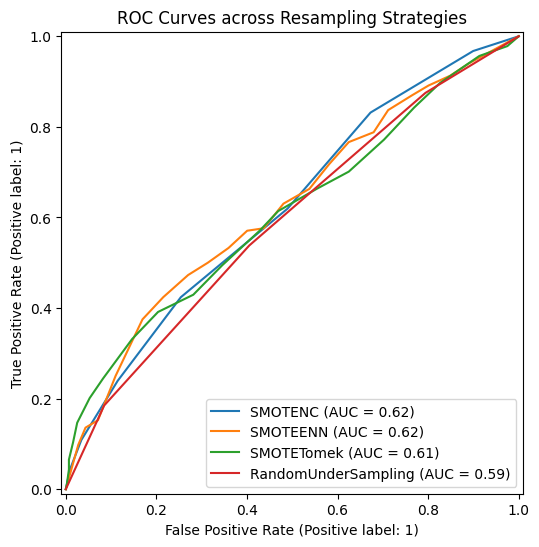

In [19]:
knn = KNeighborsClassifier()
param_grid = {
    'estimator__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'estimator__weights': ['uniform', 'distance'],        
    'estimator__metric': ['euclidean', 'manhattan']      
}
knn_ow = Overviewer(knn, param_grid, X_df, target, data)


=== SMOTENC ===
Best Params : {}
=== TRAIN PERFORMANCE ===
Accuracy: 0.5888198757763975
              precision    recall  f1-score   support

           0       0.73      0.61      0.66      1621
           1       0.41      0.55      0.47       794

    accuracy                           0.59      2415
   macro avg       0.57      0.58      0.57      2415
weighted avg       0.63      0.59      0.60      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6489533011272142
              precision    recall  f1-score   support

           0       0.79      0.69      0.73       437
           1       0.43      0.55      0.48       184

    accuracy                           0.65       621
   macro avg       0.61      0.62      0.61       621
weighted avg       0.68      0.65      0.66       621


=== SMOTEENN ===
Best Params : {}
=== TRAIN PERFORMANCE ===
Accuracy: 0.5714285714285714
              precision    recall  f1-score   support

           0       0.74      0.55      0.63      1621
    

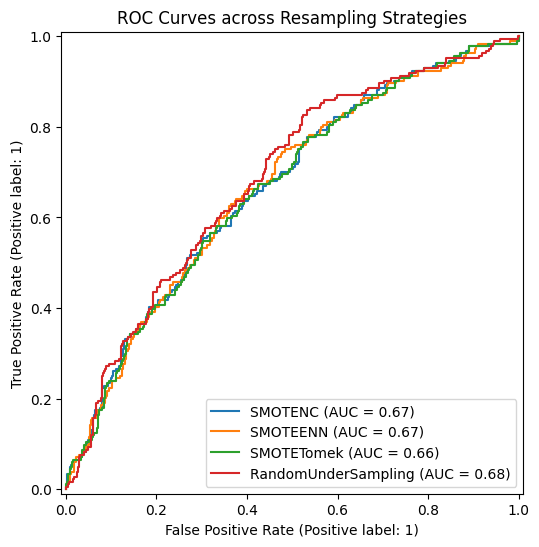

In [20]:
nb = GaussianNB()
param_grid = {}
nb_ow = Overviewer(nb, param_grid, X_df, target, data)


=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.5461697722567288
              precision    recall  f1-score   support

           0       0.74      0.50      0.60      1621
           1       0.39      0.64      0.48       794

    accuracy                           0.55      2415
   macro avg       0.56      0.57      0.54      2415
weighted avg       0.62      0.55      0.56      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6038647342995169
              precision    recall  f1-score   support

           0       0.78      0.62      0.69       437
           1       0.39      0.58      0.46       184

    accuracy                           0.60       621
   macro avg       0.58      0.60      0.57       621
weighted avg       0.66      0.60      0.62       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.3287784679089027
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1621
           1       0.33      1.00     

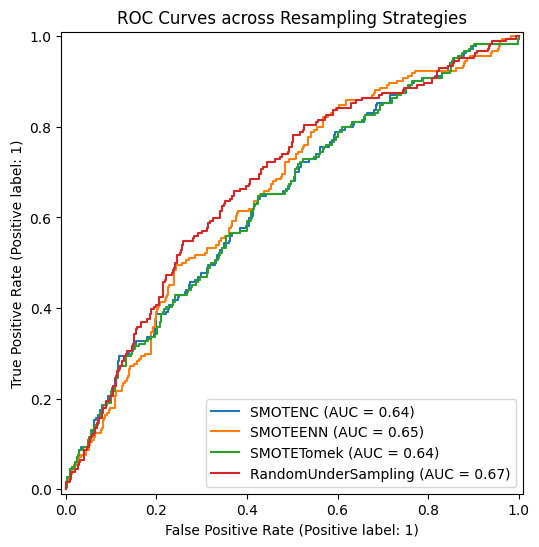

In [10]:
radial = SVC(kernel="rbf")
param_grid = {
    'estimator__C': [0.1, 1, 10, 100],
    'estimator__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
}
Overviewer(radial, param_grid, X_df, target, data)



=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6973084886128365
              precision    recall  f1-score   support

           0       0.72      0.89      0.80      1621
           1       0.58      0.30      0.39       794

    accuracy                           0.70      2415
   macro avg       0.65      0.60      0.60      2415
weighted avg       0.67      0.70      0.66      2415

=== TEST PERFORMANCE ===
Accuracy: 0.71658615136876
              precision    recall  f1-score   support

           0       0.75      0.90      0.82       437
           1       0.54      0.28      0.37       184

    accuracy                           0.72       621
   macro avg       0.65      0.59      0.59       621
weighted avg       0.69      0.72      0.68       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6318840579710145
              precision    recall  f1-score   support

           0       0.72      0.74      0.73      1621
           1       0.44      0.41      0

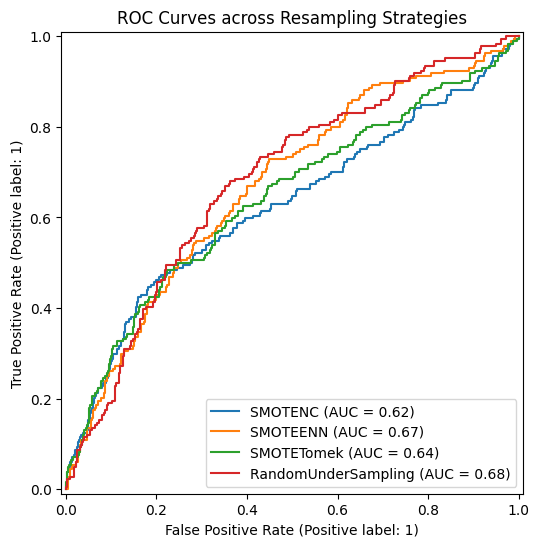

In [11]:
polynomial = SVC(kernel="poly", max_iter=10000)
param_grid = {
    'estimator__C': [0.1, 1, 10, 100],
    'estimator__degree': [2, 3],
    'estimator__gamma': ['scale', 0.01, 0.1, 1],
    'estimator__coef0': [0, 1, 2]
}
Overviewer(polynomial, param_grid, X_df, target, data, "f1_macro")


=== SMOTENC ===
[LightGBM] [Info] Number of positive: 1621, number of negative: 1621
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1117
[LightGBM] [Info] Number of data points in the train set: 3242, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
=== TRAIN PERFORMANCE ===
Accuracy: 0.7329192546583851
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      1621
           1       0.60      0.54      0.57       794

    accuracy                           0.73      2415
   macro avg       0.70      0.68      0.69      2415
weighted avg       0.73      0.73      0.73      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6714975845410628
              precision    recall  f1-score   s

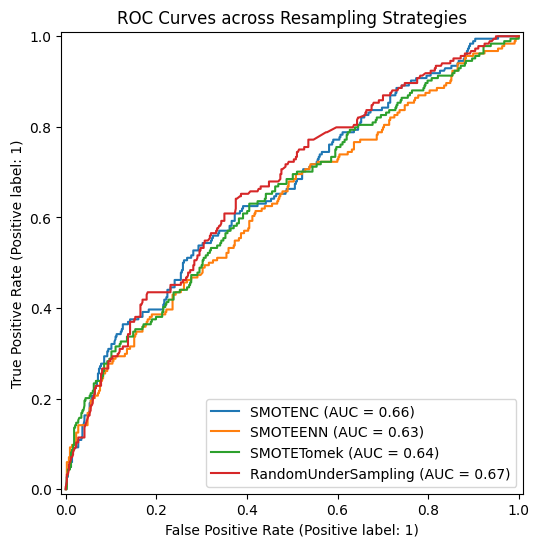

In [ ]:
lgbm = lgb.LGBMClassifier(importance_type=-1)
param_grid = {
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__n_estimators': [100, 500, 1000],
    'estimator__num_leaves': [31, 63, 127],
    'estimator__max_depth': [-1, 5, 8],
    'estimator__min_child_samples': [10, 20, 30],
    'estimator__subsample': [0.7, 0.8, 1.0],
    'estimator__colsample_bytree': [0.7, 0.8, 1.0]
}

Overviewer(lgbm, param_grid, X_df, target, data, scoring="f1_macro", search="random")



=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6952380952380952
              precision    recall  f1-score   support

           0       0.75      0.81      0.78      1621
           1       0.54      0.46      0.50       794

    accuracy                           0.70      2415
   macro avg       0.65      0.64      0.64      2415
weighted avg       0.68      0.70      0.69      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6827697262479872
              precision    recall  f1-score   support

           0       0.76      0.81      0.78       437
           1       0.46      0.39      0.42       184

    accuracy                           0.68       621
   macro avg       0.61      0.60      0.60       621
weighted avg       0.67      0.68      0.67       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6385093167701863
              precision    recall  f1-score   support

           0       0.76      0.67      0.71      1621
           1       0.46      0.58     

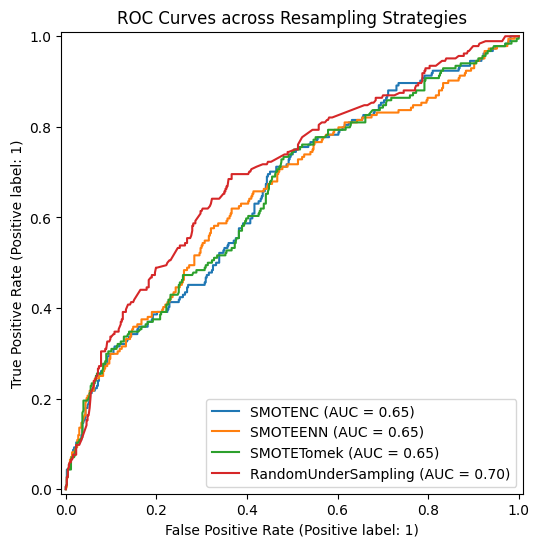

In [13]:
from random import randint, uniform
xgb = xgboost.XGBClassifier()
param_grid = {
    'estimator__learning_rate': [0.01, 0.05, 0.1],
    'estimator__n_estimators': [100, 200, 500],
    'estimator__max_depth': [3, 5, 7],
    'estimator__min_child_weight': [1, 3, 5],
    'estimator__subsample': [0.7, 0.8, 1.0],
    'estimator__colsample_bytree': [0.7, 0.8, 1.0],
    'estimator__gamma': [0, 0.1, 0.2]
}
Overviewer(xgb, param_grid, X_df, target, data, "f1_macro","random")


=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.6028985507246377
              precision    recall  f1-score   support

           0       0.76      0.60      0.67      1621
           1       0.43      0.60      0.50       794

    accuracy                           0.60      2415
   macro avg       0.59      0.60      0.59      2415
weighted avg       0.65      0.60      0.61      2415

=== TEST PERFORMANCE ===
Accuracy: 0.642512077294686
              precision    recall  f1-score   support

           0       0.79      0.67      0.73       437
           1       0.42      0.58      0.49       184

    accuracy                           0.64       621
   macro avg       0.61      0.62      0.61       621
weighted avg       0.68      0.64      0.66       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.4749482401656315
              precision    recall  f1-score   support

           0       0.81      0.28      0.42      1621
           1       0.37      0.87      

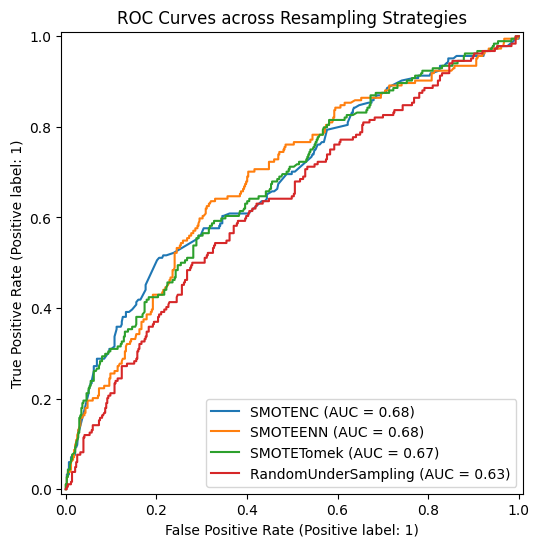

In [14]:
Overviewer(xgb, param_grid, X_df, target, data, "recall", "random")


=== SMOTENC ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.7619047619047619
              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1621
           1       0.66      0.56      0.61       794

    accuracy                           0.76      2415
   macro avg       0.73      0.71      0.72      2415
weighted avg       0.75      0.76      0.76      2415

=== TEST PERFORMANCE ===
Accuracy: 0.6698872785829307
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       437
           1       0.43      0.36      0.40       184

    accuracy                           0.67       621
   macro avg       0.59      0.58      0.58       621
weighted avg       0.66      0.67      0.66       621


=== SMOTEENN ===
=== TRAIN PERFORMANCE ===
Accuracy: 0.687784679089027
              precision    recall  f1-score   support

           0       0.77      0.75      0.76      1621
           1       0.52      0.55      

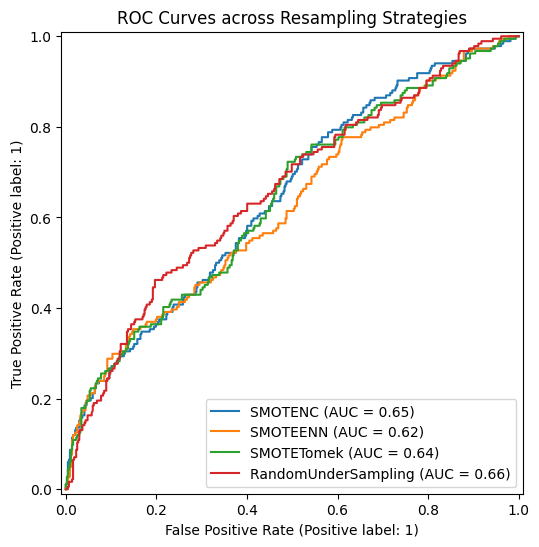

In [15]:
import catboost
cat = catboost.CatBoostClassifier(iterations=10, verbose=False)
param_grid = {
    'estimator__iterations': [500, 1000],
    'estimator__learning_rate': [0.03, 0.1],
    'estimator__depth': [4, 6, 8],
    'estimator__l2_leaf_reg': [1, 3, 5]
}

Overviewer(cat, param_grid, X_df, target, data, "f1_macro", "grid")